In [6]:

from torch.utils.data import DataLoader
import torch
import torch.nn as nn
from torch.optim import Adam
from tqdm import tqdm


from refined_progan import Generator, Discriminator
from CityScapes import CityScapesMultiScaleDataset

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
list_to_device = lambda x,device :[img.to(device) for img in x]

In [2]:
z_dim =512
channels = [512,256,128,64,32,32,32]
batch_size =8

In [3]:
dataset = CityScapesMultiScaleDataset()
loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)


Dataset initialized with 19998 samples. Labels enabled: False


In [4]:

gen = Generator(z_dim,channels).to(device)
disc = Discriminator(channels).to(device)

gen_optimizer = Adam(gen.parameters(), lr=1e-4, betas=(0.5, 0.999))
disc_optimizer = Adam(disc.parameters(), lr=1e-4, betas=(0.5, 0.999))
noise =  torch.randn(1,z_dim,1,1).to(device)
fake = gen(noise)
disc_fake = disc(fake)

real,_ = next(iter(loader))
real = list_to_device(real,device)
disc_real = disc(real)


/mnt/mydrive/ilias/projects/unsupervised_learning/ECCV/refined_progan/discriminator.py:35: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1839.)
  batch_statistics =torch.std(x,dim=0).mean().repeat(x.shape[0],1,x.shape[2],x.shape[3])


In [ ]:
loop = tqdm(loader)
loop.set_description("Training")

for i, (real,_) in enumerate(loop):
    real = list_to_device(real,device)
    current_batch_size = real[0].shape[0]
    

    disc_optimizer.zero_grad()
    noise = torch.randn(current_batch_size, z_dim,1,1).to(device)
    fake = gen(noise)
    disc_fake = disc(fake)

    disc_real = disc(real)
    loss_disc =(
    0.5 * (torch.mean(disc_fake) - torch.mean(disc_real))
    + (0.001 * torch.mean(disc_real ** 2))
    )

    loss_disc.backward()
    disc_optimizer.step()

    gen_optimizer.zero_grad()
    noise = torch.randn(current_batch_size, z_dim,1,1).to(device)
    fake = gen(noise)
    disc_fake = disc(fake)
    loss_gen = - torch.mean(disc_fake)

    loss_gen.backward()
    gen_optimizer.step()
    loop.set_postfix(loss_disc=loss_disc.item(),loss_gen=loss_gen.item())





Training:   0%|          | 1/2500 [00:00<06:30,  6.40it/s, loss_disc=-9.53, loss_gen=-13.1]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [5.9604645e-06..1.9897335].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.9802322e-07..1.9973657].


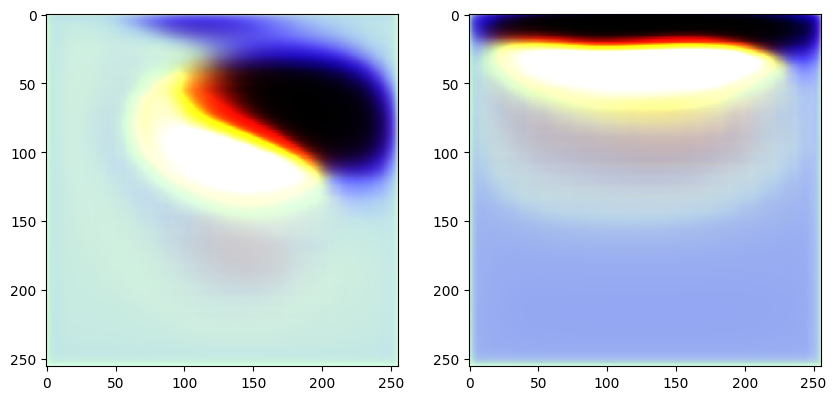

In [36]:
import matplotlib.pyplot as plt
with torch.no_grad():
    noise =torch.randn(2,z_dim,1,1).to(device)
    fake = gen(noise)
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(fake[-1][0].permute(1,2,0).cpu().numpy()+1)
ax[1].imshow(fake[-1][1].permute(1,2,0).cpu().numpy()+1)
